<a id="section1"></a>
## 1. Load and Inspect Data

In [1]:
# Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import joblib

# Statistical Analysis
from scipy import stats
from scipy.stats import skew, kurtosis
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
from sklearn.base import BaseEstimator, RegressorMixin

# Gradient Boosting
import xgboost as xgb

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"XGBoost version: {xgb.__version__}")

✓ All libraries imported successfully!
Pandas version: 2.2.3
NumPy version: 2.1.3
XGBoost version: 3.1.2


In [2]:
# Load datasets
data_path = Path('./dataset')

train_df = pd.read_csv(data_path / 'train.csv')
test_df = pd.read_csv(data_path / 'test.csv')

print("="*80)
print("DATASET LOADED SUCCESSFULLY")
print("="*80)
print(f"\nTrain Set Shape: {train_df.shape}")
print(f"Test Set Shape: {test_df.shape}")
print(f"\nTarget Variable: SalePrice")
print(f"Number of Features: {train_df.shape[1] - 1}")
print(f"Number of Training Samples: {train_df.shape[0]}")
print(f"Number of Test Samples: {test_df.shape[0]}")

# Display first few rows
train_df.head()

DATASET LOADED SUCCESSFULLY

Train Set Shape: (1460, 81)
Test Set Shape: (1459, 80)

Target Variable: SalePrice
Number of Features: 80
Number of Training Samples: 1460
Number of Test Samples: 1459


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<a id="section2"></a>
## 2. Exploratory Data Analysis (EDA)

FEATURE TYPE CLASSIFICATION

Numeric Features (36): ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2']...

Categorical Features (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']...

SALE PRICE STATISTICS
Mean: $180,921.20
Median: $163,000.00
Skewness: 1.8829


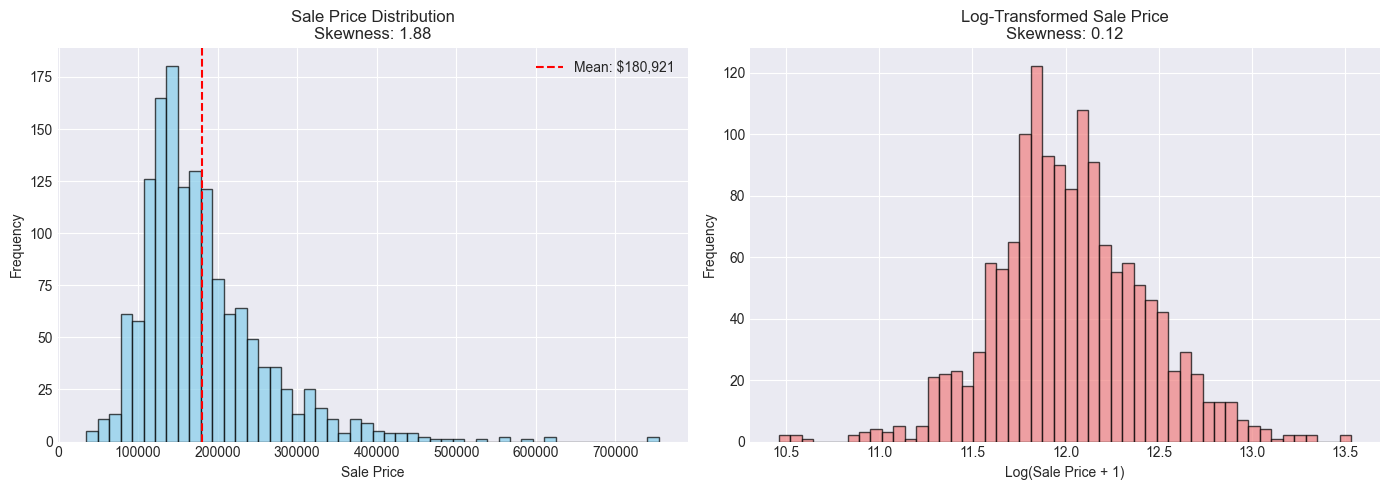


✓ Target variable analysis complete
Recommendation: Apply log transformation


In [3]:
# Identify numeric and categorical columns
numeric_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()

# Remove Id and SalePrice from features
if 'Id' in numeric_features:
    numeric_features.remove('Id')
if 'SalePrice' in numeric_features:
    numeric_features.remove('SalePrice')

print("="*80)
print("FEATURE TYPE CLASSIFICATION")
print("="*80)
print(f"\nNumeric Features ({len(numeric_features)}): {numeric_features[:10]}...")
print(f"\nCategorical Features ({len(categorical_features)}): {categorical_features[:10]}...")

# Analyze SalePrice
sale_price = train_df['SalePrice']
print(f"\n{'='*80}")
print("SALE PRICE STATISTICS")
print("="*80)
print(f"Mean: ${sale_price.mean():,.2f}")
print(f"Median: ${sale_price.median():,.2f}")
print(f"Skewness: {sale_price.skew():.4f}")

# Visualize Sale Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(sale_price, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
ax1.axvline(sale_price.mean(), color='red', linestyle='--', label=f'Mean: ${sale_price.mean():,.0f}')
ax1.set_xlabel('Sale Price')
ax1.set_ylabel('Frequency')
ax1.set_title(f'Sale Price Distribution\nSkewness: {sale_price.skew():.2f}')
ax1.legend()

ax2 = axes[1]
log_price = np.log1p(sale_price)
ax2.hist(log_price, bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
ax2.set_xlabel('Log(Sale Price + 1)')
ax2.set_ylabel('Frequency')
ax2.set_title(f'Log-Transformed Sale Price\nSkewness: {log_price.skew():.2f}')

plt.tight_layout()
plt.show()

print("\n✓ Target variable analysis complete")
print(f"Recommendation: {'Apply log transformation' if sale_price.skew() > 0.5 else 'No transformation needed'}")

MISSING VALUE REPORT
Total features with missing values: 19

Top 10 features with highest missing percentage:
                   Feature  Missing_Count  Missing_Percentage
PoolQC              PoolQC           1453           99.520548
MiscFeature    MiscFeature           1406           96.301370
Alley                Alley           1369           93.767123
Fence                Fence           1179           80.753425
MasVnrType      MasVnrType            872           59.726027
FireplaceQu    FireplaceQu            690           47.260274
LotFrontage    LotFrontage            259           17.739726
GarageQual      GarageQual             81            5.547945
GarageFinish  GarageFinish             81            5.547945
GarageType      GarageType             81            5.547945

TOP 15 FEATURES CORRELATED WITH SALEPRICE
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF       

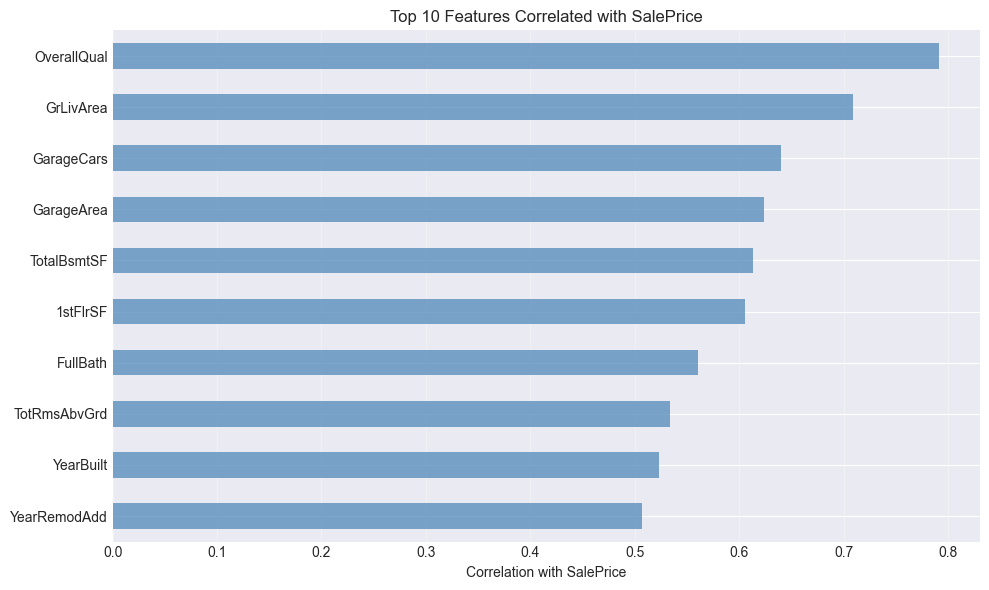


✓ EDA complete


In [4]:
# Missing value analysis
missing_data = pd.DataFrame({
    'Feature': train_df.columns,
    'Missing_Count': train_df.isnull().sum(),
    'Missing_Percentage': 100 * train_df.isnull().sum() / len(train_df)
})

missing_data = missing_data.sort_values('Missing_Percentage', ascending=False)
missing_with_values = missing_data[missing_data['Missing_Count'] > 0]

print("="*80)
print("MISSING VALUE REPORT")
print("="*80)
print(f"Total features with missing values: {len(missing_with_values)}")
print(f"\nTop 10 features with highest missing percentage:")
print(missing_with_values.head(10))

# Correlation analysis
numeric_train = train_df[numeric_features + ['SalePrice']].copy()
corr_matrix = numeric_train.corr()
price_corr = corr_matrix['SalePrice'].sort_values(ascending=False)

print(f"\n{'='*80}")
print("TOP 15 FEATURES CORRELATED WITH SALEPRICE")
print("="*80)
print(price_corr.head(16))

# Visualize top correlations
plt.figure(figsize=(10, 6))
top_corr = price_corr.head(11)[1:]  # Exclude SalePrice itself
top_corr.sort_values().plot(kind='barh', color='steelblue', alpha=0.7)
plt.xlabel('Correlation with SalePrice')
plt.title('Top 10 Features Correlated with SalePrice')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ EDA complete")

<a id="section3"></a>
## 3. Missing Value Treatment

In [5]:
# Create copies for preprocessing
train_processed = train_df.copy()
test_processed = test_df.copy()

# Strategy 1: Features where NA means "None" (absence of feature)
na_means_none = {
    'Alley': 'No_Alley',
    'BsmtQual': 'No_Basement',
    'BsmtCond': 'No_Basement',
    'BsmtExposure': 'No_Basement',
    'BsmtFinType1': 'No_Basement',
    'BsmtFinType2': 'No_Basement',
    'FireplaceQu': 'No_Fireplace',
    'GarageType': 'No_Garage',
    'GarageFinish': 'No_Garage',
    'GarageQual': 'No_Garage',
    'GarageCond': 'No_Garage',
    'PoolQC': 'No_Pool',
    'Fence': 'No_Fence',
    'MiscFeature': 'None',
    'GarageArea': 0,
    'GarageCars': 0,
    'BsmtFinSF1': 0,
    'BsmtFinSF2': 0,
    'BsmtUnfSF': 0,
    'TotalBsmtSF': 0,
    'BsmtFullBath': 0,
    'BsmtHalfBath': 0,
    'MasVnrArea': 0
}

# Apply NA = None/0 strategy
for feature, fill_value in na_means_none.items():
    if feature in train_processed.columns:
        train_processed[feature].fillna(fill_value, inplace=True)
    if feature in test_processed.columns:
        test_processed[feature].fillna(fill_value, inplace=True)

# Special handling for GarageYrBlt
for df in [train_processed, test_processed]:
    if 'GarageYrBlt' in df.columns and 'YearBuilt' in df.columns:
        df['GarageYrBlt'].fillna(df['YearBuilt'], inplace=True)

# Strategy 2: Impute with mode for categorical features with low missingness
for col in categorical_features:
    if col in train_processed.columns:
        missing_pct = 100 * train_processed[col].isnull().sum() / len(train_processed)
        if 0 < missing_pct < 5:
            mode_value = train_processed[col].mode()[0] if len(train_processed[col].mode()) > 0 else 'Missing'
            train_processed[col].fillna(mode_value, inplace=True)
            if col in test_processed.columns:
                test_processed[col].fillna(mode_value, inplace=True)

# Strategy 3: Impute with median for numeric features with low missingness
for col in numeric_features:
    if col in train_processed.columns:
        missing_pct = 100 * train_processed[col].isnull().sum() / len(train_processed)
        if 0 < missing_pct < 5:
            median_value = train_processed[col].median()
            train_processed[col].fillna(median_value, inplace=True)
            if col in test_processed.columns:
                test_processed[col].fillna(median_value, inplace=True)

# Fill remaining missing values
for col in train_processed.columns:
    if train_processed[col].isnull().sum() > 0:
        if train_processed[col].dtype == 'object':
            train_processed[col].fillna('Unknown', inplace=True)
        else:
            train_processed[col].fillna(train_processed[col].median(), inplace=True)

for col in test_processed.columns:
    if test_processed[col].isnull().sum() > 0:
        if test_processed[col].dtype == 'object':
            test_processed[col].fillna('Unknown', inplace=True)
        else:
            test_processed[col].fillna(test_processed[col].median(), inplace=True)

print(f"{'='*80}")
print("MISSING VALUES AFTER TREATMENT")
print(f"{'='*80}")
print(f"Train set: {train_processed.isnull().sum().sum()} missing")
print(f"Test set: {test_processed.isnull().sum().sum()} missing")
print("\n✓ All missing values handled")

MISSING VALUES AFTER TREATMENT
Train set: 0 missing
Test set: 0 missing

✓ All missing values handled


<a id="section4"></a>
## 4. Categorical Encoding

In [6]:
# Define ordinal features with their order
ordinal_features = {
    'ExterQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'ExterCond': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtQual': ['No_Basement', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtCond': ['No_Basement', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'HeatingQC': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'KitchenQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'FireplaceQu': ['No_Fireplace', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageQual': ['No_Garage', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageCond': ['No_Garage', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
}

# Apply ordinal encoding
for feature, categories in ordinal_features.items():
    if feature in train_processed.columns:
        mapping = {cat: idx for idx, cat in enumerate(categories)}
        train_processed[feature] = train_processed[feature].map(mapping)
        train_processed[feature].fillna(-1, inplace=True)
        
        if feature in test_processed.columns:
            test_processed[feature] = test_processed[feature].map(mapping)
            test_processed[feature].fillna(-1, inplace=True)

print(f"✓ Encoded {len(ordinal_features)} ordinal features")

# One-hot encode remaining categorical features
remaining_categorical = [col for col in train_processed.select_dtypes(include=['object']).columns 
                        if col not in ['Id', 'SalePrice']]

low_cardinality = [col for col in remaining_categorical if train_processed[col].nunique() < 10]
high_cardinality = [col for col in remaining_categorical if train_processed[col].nunique() >= 10]

if low_cardinality:
    train_encoded = pd.get_dummies(train_processed, columns=low_cardinality, drop_first=True)
    test_encoded = pd.get_dummies(test_processed, columns=low_cardinality, drop_first=True)
    
    # Align columns
    train_cols = set(train_encoded.columns)
    test_cols = set(test_encoded.columns)
    
    for col in train_cols - test_cols:
        if col != 'SalePrice':
            test_encoded[col] = 0
    
    for col in test_cols - train_cols:
        test_encoded.drop(col, axis=1, inplace=True)
    
    test_encoded = test_encoded[train_encoded.columns.drop('SalePrice', errors='ignore')]
    train_processed = train_encoded
    test_processed = test_encoded
    
    print(f"✓ One-hot encoded {len(low_cardinality)} features")

# Label encode high cardinality features
for col in high_cardinality:
    if col in train_processed.columns:
        le = LabelEncoder()
        train_processed[col] = le.fit_transform(train_processed[col].astype(str))
        
        if col in test_processed.columns:
            test_processed[col] = test_processed[col].astype(str).apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )

print(f"✓ Label encoded {len(high_cardinality)} high-cardinality features")
print(f"\nProcessed train shape: {train_processed.shape}")
print(f"Processed test shape: {test_processed.shape}")

✓ Encoded 9 ordinal features
✓ One-hot encoded 31 features
✓ Label encoded 3 high-cardinality features

Processed train shape: (1460, 183)
Processed test shape: (1459, 182)


<a id="section5"></a>
## 5. Feature Engineering

In [7]:
# Engineer new features
def engineer_features(df):
    df_eng = df.copy()
    
    # Total Square Footage
    if all(col in df_eng.columns for col in ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']):
        df_eng['TotalSF'] = df_eng['TotalBsmtSF'] + df_eng['1stFlrSF'] + df_eng['2ndFlrSF']
    
    # Total Bathrooms
    if all(col in df_eng.columns for col in ['BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath']):
        df_eng['TotalBath'] = df_eng['BsmtFullBath'] + 0.5*df_eng['BsmtHalfBath'] + df_eng['FullBath'] + 0.5*df_eng['HalfBath']
    
    # House Age
    if all(col in df_eng.columns for col in ['YrSold', 'YearBuilt']):
        df_eng['HouseAge'] = df_eng['YrSold'] - df_eng['YearBuilt']
        df_eng['HouseAge'] = df_eng['HouseAge'].clip(lower=0)
    
    # Years Since Remodel
    if all(col in df_eng.columns for col in ['YrSold', 'YearRemodAdd']):
        df_eng['YearsSinceRemodel'] = df_eng['YrSold'] - df_eng['YearRemodAdd']
        df_eng['YearsSinceRemodel'] = df_eng['YearsSinceRemodel'].clip(lower=0)
    
    # Overall Quality × Total SF
    if all(col in df_eng.columns for col in ['OverallQual', 'TotalSF']):
        df_eng['QualityTimesSize'] = df_eng['OverallQual'] * df_eng['TotalSF']
    
    # Living Area Per Room
    if all(col in df_eng.columns for col in ['GrLivArea', 'TotRmsAbvGrd']):
        df_eng['AreaPerRoom'] = df_eng['GrLivArea'] / (df_eng['TotRmsAbvGrd'] + 1)
    
    return df_eng

# Apply feature engineering
train_engineered = engineer_features(train_processed)
test_engineered = engineer_features(test_processed)

new_cols = [col for col in train_engineered.columns if col not in train_processed.columns]
print("="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)
print(f"New Features Created: {len(new_cols)}")
for col in new_cols:
    print(f"  - {col}")

if 'SalePrice' in train_engineered.columns:
    new_feature_corr = train_engineered[new_cols + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)[1:]
    print(f"\nCorrelation of New Features with SalePrice:")
    print(new_feature_corr)

print("\n✓ Feature engineering complete")

FEATURE ENGINEERING SUMMARY
New Features Created: 6
  - TotalSF
  - TotalBath
  - HouseAge
  - YearsSinceRemodel
  - QualityTimesSize
  - AreaPerRoom

Correlation of New Features with SalePrice:
QualityTimesSize     0.856148
TotalSF              0.782260
TotalBath            0.631731
AreaPerRoom          0.616235
YearsSinceRemodel   -0.509096
HouseAge            -0.523350
Name: SalePrice, dtype: float64

✓ Feature engineering complete


<a id="section6"></a>
## 6. Model Training - Elastic Net

In [8]:
# Prepare data for modeling
X_full = train_engineered.drop(['Id', 'SalePrice'], axis=1, errors='ignore')
y_full = train_engineered['SalePrice']
X_test_final = test_engineered.drop(['Id'], axis=1, errors='ignore')

# Ensure all columns are numeric
for col in X_full.select_dtypes(include=['object']).columns:
    X_full[col] = pd.to_numeric(X_full[col], errors='coerce').fillna(0)
for col in X_test_final.select_dtypes(include=['object']).columns:
    X_test_final[col] = pd.to_numeric(X_test_final[col], errors='coerce').fillna(0)

# Align features
common_features = list(set(X_full.columns).intersection(set(X_test_final.columns)))
X_full = X_full[common_features]
X_test_final = X_test_final[common_features]

print(f"Final feature count: {len(common_features)}")
print(f"X_full shape: {X_full.shape}")
print(f"X_test_final shape: {X_test_final.shape}")

# Apply log transformation to target
y_log = np.log1p(y_full)
print(f"\nTarget skewness before log: {y_full.skew():.4f}")
print(f"Target skewness after log: {y_log.skew():.4f}")

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(X_full, y_log, test_size=0.2, random_state=RANDOM_STATE)

# Feature scaling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_full_scaled = scaler.fit_transform(X_full)
X_test_scaled = scaler.transform(X_test_final)

print("\n✓ Data preparation complete")

Final feature count: 187
X_full shape: (1460, 187)
X_test_final shape: (1459, 187)

Target skewness before log: 1.8829
Target skewness after log: 0.1213

✓ Data preparation complete


In [9]:
# Elastic Net Hyperparameter Tuning
print("="*80)
print("ELASTIC NET - HYPERPARAMETER TUNING")
print("="*80)

elastic_params = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.99]
}

elastic_net = ElasticNet(max_iter=10000, random_state=RANDOM_STATE)
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search_elastic = GridSearchCV(
    estimator=elastic_net,
    param_grid=elastic_params,
    scoring='neg_mean_squared_error',
    cv=kfold,
    n_jobs=-1,
    verbose=1
)

grid_search_elastic.fit(X_train_scaled, y_train)

print(f"\nBest Parameters:")
print(f"  Alpha: {grid_search_elastic.best_params_['alpha']}")
print(f"  L1 Ratio: {grid_search_elastic.best_params_['l1_ratio']}")
print(f"  Best CV RMSE: {np.sqrt(-grid_search_elastic.best_score_):.4f}")

# Train final model
best_elastic = grid_search_elastic.best_estimator_
best_elastic.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_elastic = best_elastic.predict(X_train_scaled)
y_val_pred_elastic = best_elastic.predict(X_val_scaled)

# Metrics
train_rmse_elastic = np.sqrt(mean_squared_error(y_train, y_train_pred_elastic))
val_rmse_elastic = np.sqrt(mean_squared_error(y_val, y_val_pred_elastic))
val_r2_elastic = r2_score(y_val, y_val_pred_elastic)

print(f"\nElastic Net Performance:")
print(f"  Train RMSE: {train_rmse_elastic:.4f}")
print(f"  Val RMSE: {val_rmse_elastic:.4f}")
print(f"  Val R²: {val_r2_elastic:.4f}")

# Cross-validation
cv_scores_elastic = cross_val_score(best_elastic, X_full_scaled, y_log, 
                                   cv=kfold, scoring='neg_mean_squared_error', n_jobs=-1)
cv_rmse_elastic = np.sqrt(-cv_scores_elastic)
print(f"  5-Fold CV RMSE: {cv_rmse_elastic.mean():.4f} (+/- {cv_rmse_elastic.std():.4f})")

print("\n✓ Elastic Net trained successfully")

ELASTIC NET - HYPERPARAMETER TUNING
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters:
  Alpha: 0.01
  L1 Ratio: 0.1
  Best CV RMSE: 0.1428

Elastic Net Performance:
  Train RMSE: 0.1253
  Val RMSE: 0.1418
  Val R²: 0.8923
  5-Fold CV RMSE: 0.1486 (+/- 0.0418)

✓ Elastic Net trained successfully


<a id="section7"></a>
## 7. Model Training - XGBoost

In [10]:
# XGBoost Hyperparameter Tuning
print("="*80)
print("XGBOOST - HYPERPARAMETER TUNING")
print("="*80)

xgb_params = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [500, 1000, 1500],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
    tree_method='hist'
)

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_params,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=kfold,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

random_search_xgb.fit(X_train, y_train)

print(f"\nBest Parameters:")
for param, value in random_search_xgb.best_params_.items():
    print(f"  {param}: {value}")
print(f"  Best CV RMSE: {np.sqrt(-random_search_xgb.best_score_):.4f}")

# Train final model
best_xgb = xgb.XGBRegressor(
    **random_search_xgb.best_params_,
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
    tree_method='hist'
)

best_xgb.fit(X_train, y_train)

# Predictions
y_train_pred_xgb = best_xgb.predict(X_train)
y_val_pred_xgb = best_xgb.predict(X_val)

# Metrics
train_rmse_xgb = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
val_rmse_xgb = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb))
val_r2_xgb = r2_score(y_val, y_val_pred_xgb)

print(f"\nXGBoost Performance:")
print(f"  Train RMSE: {train_rmse_xgb:.4f}")
print(f"  Val RMSE: {val_rmse_xgb:.4f}")
print(f"  Val R²: {val_r2_xgb:.4f}")

# Cross-validation
cv_scores_xgb = cross_val_score(best_xgb, X_full, y_log, 
                                cv=kfold, scoring='neg_mean_squared_error', n_jobs=-1)
cv_rmse_xgb = np.sqrt(-cv_scores_xgb)
print(f"  5-Fold CV RMSE: {cv_rmse_xgb.mean():.4f} (+/- {cv_rmse_xgb.std():.4f})")

print("\n✓ XGBoost trained successfully")

XGBOOST - HYPERPARAMETER TUNING
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters:
  subsample: 0.7
  n_estimators: 1500
  max_depth: 3
  learning_rate: 0.01
  colsample_bytree: 0.7
  Best CV RMSE: 0.1231

XGBoost Performance:
  Train RMSE: 0.0684
  Val RMSE: 0.1319
  Val R²: 0.9068
  5-Fold CV RMSE: 0.1290 (+/- 0.0161)

✓ XGBoost trained successfully


<a id="section8"></a>
## 8. Save Trained Models

In [11]:
# Create models directory
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

print("="*80)
print("SAVING MODELS")
print("="*80)

# Save models
joblib.dump(best_xgb, models_dir / 'xgboost_model.pkl')
joblib.dump(best_elastic, models_dir / 'elastic_net_model.pkl')
joblib.dump(scaler, models_dir / 'scaler.pkl')

# Save feature info
feature_info = {
    'feature_names': X_full.columns.tolist(),
    'n_features': len(X_full.columns),
    'target_transformation': 'log1p'
}
joblib.dump(feature_info, models_dir / 'feature_info.pkl')

# Save model parameters
model_params = {
    'xgboost_params': best_xgb.get_params(),
    'elastic_net_params': best_elastic.get_params(),
    'xgb_cv_rmse': f"{cv_rmse_xgb.mean():.4f} (+/- {cv_rmse_xgb.std():.4f})",
    'elastic_cv_rmse': f"{cv_rmse_elastic.mean():.4f} (+/- {cv_rmse_elastic.std():.4f})"
}
joblib.dump(model_params, models_dir / 'model_parameters.pkl')

print("✓ Models saved successfully!")
print(f"  - xgboost_model.pkl")
print(f"  - elastic_net_model.pkl")
print(f"  - scaler.pkl")
print(f"  - feature_info.pkl")
print(f"  - model_parameters.pkl")

SAVING MODELS
✓ Models saved successfully!
  - xgboost_model.pkl
  - elastic_net_model.pkl
  - scaler.pkl
  - feature_info.pkl
  - model_parameters.pkl


<a id="section9"></a>
## 9. Model Evaluation

MODEL COMPARISON
      Model  Train_RMSE  Val_RMSE   Val_R2  CV_RMSE_Mean
Elastic Net    0.125329  0.141753 0.892322      0.148552
    XGBoost    0.068440  0.131884 0.906793      0.128999


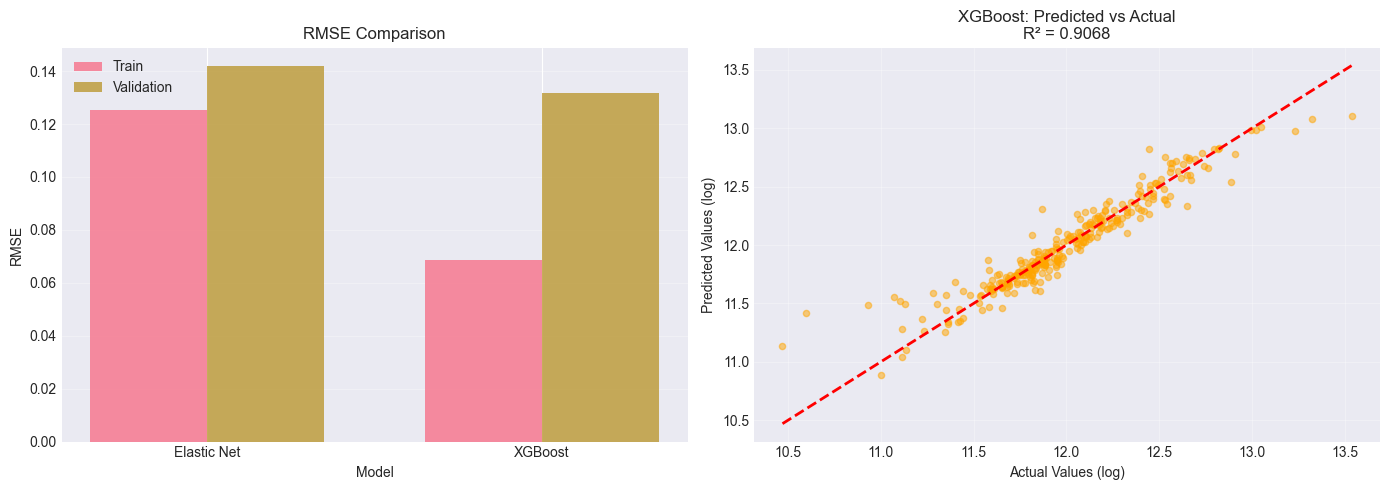


Best Model: XGBoost

✓ Model evaluation complete


In [12]:
# Model Comparison
comparison_df = pd.DataFrame({
    'Model': ['Elastic Net', 'XGBoost'],
    'Train_RMSE': [train_rmse_elastic, train_rmse_xgb],
    'Val_RMSE': [val_rmse_elastic, val_rmse_xgb],
    'Val_R2': [val_r2_elastic, val_r2_xgb],
    'CV_RMSE_Mean': [cv_rmse_elastic.mean(), cv_rmse_xgb.mean()]
})

print("="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE Comparison
ax1 = axes[0]
x_pos = np.arange(len(comparison_df))
width = 0.35
ax1.bar(x_pos - width/2, comparison_df['Train_RMSE'], width, label='Train', alpha=0.8)
ax1.bar(x_pos + width/2, comparison_df['Val_RMSE'], width, label='Validation', alpha=0.8)
ax1.set_xlabel('Model')
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE Comparison')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(comparison_df['Model'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Predicted vs Actual (XGBoost)
ax2 = axes[1]
ax2.scatter(y_val, y_val_pred_xgb, alpha=0.5, s=20, color='orange')
ax2.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Values (log)')
ax2.set_ylabel('Predicted Values (log)')
ax2.set_title(f'XGBoost: Predicted vs Actual\nR² = {val_r2_xgb:.4f}')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_model = comparison_df.loc[comparison_df['Val_RMSE'].idxmin(), 'Model']
print(f"\nBest Model: {best_model}")
print("\n✓ Model evaluation complete")

<a id="section10"></a>
## 10. Partial Dependence Plots (PDP)

Global explainability using Partial Dependence Plots to understand feature effects.

PARTIAL DEPENDENCE PLOTS - GLOBAL EXPLAINABILITY

Top 15 Features - XGBoost Importance:
              Feature  Importance
19   QualityTimesSize    0.119362
177         ExterQual    0.091039
128       OverallQual    0.088559
66            TotalSF    0.061912
158       KitchenQual    0.049773
106      CentralAir_Y    0.043486
32         GarageCond    0.033328
75          TotalBath    0.029733
131          BsmtQual    0.028931
178       FireplaceQu    0.024836
8          GarageCars    0.024413
87        MSZoning_RM    0.020644
43         GarageQual    0.018104
70         Fireplaces    0.013855
69       KitchenAbvGr    0.013529


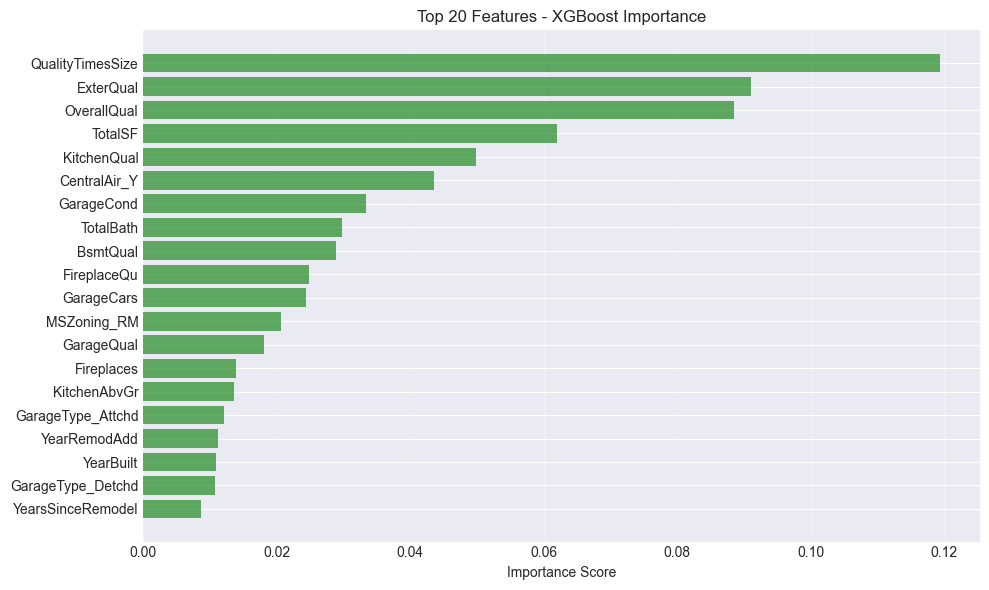

In [13]:
print("="*80)
print("PARTIAL DEPENDENCE PLOTS - GLOBAL EXPLAINABILITY")
print("="*80)

# Get top features from XGBoost
xgb_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Features - XGBoost Importance:")
print(xgb_feature_importance.head(15))

# Visualize feature importance
plt.figure(figsize=(10, 6))
top_20 = xgb_feature_importance.head(20)
plt.barh(range(len(top_20)), top_20['Importance'], color='forestgreen', alpha=0.7)
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Importance Score')
plt.title('Top 20 Features - XGBoost Importance')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


Generating Partial Dependence Plots for top 8 features...


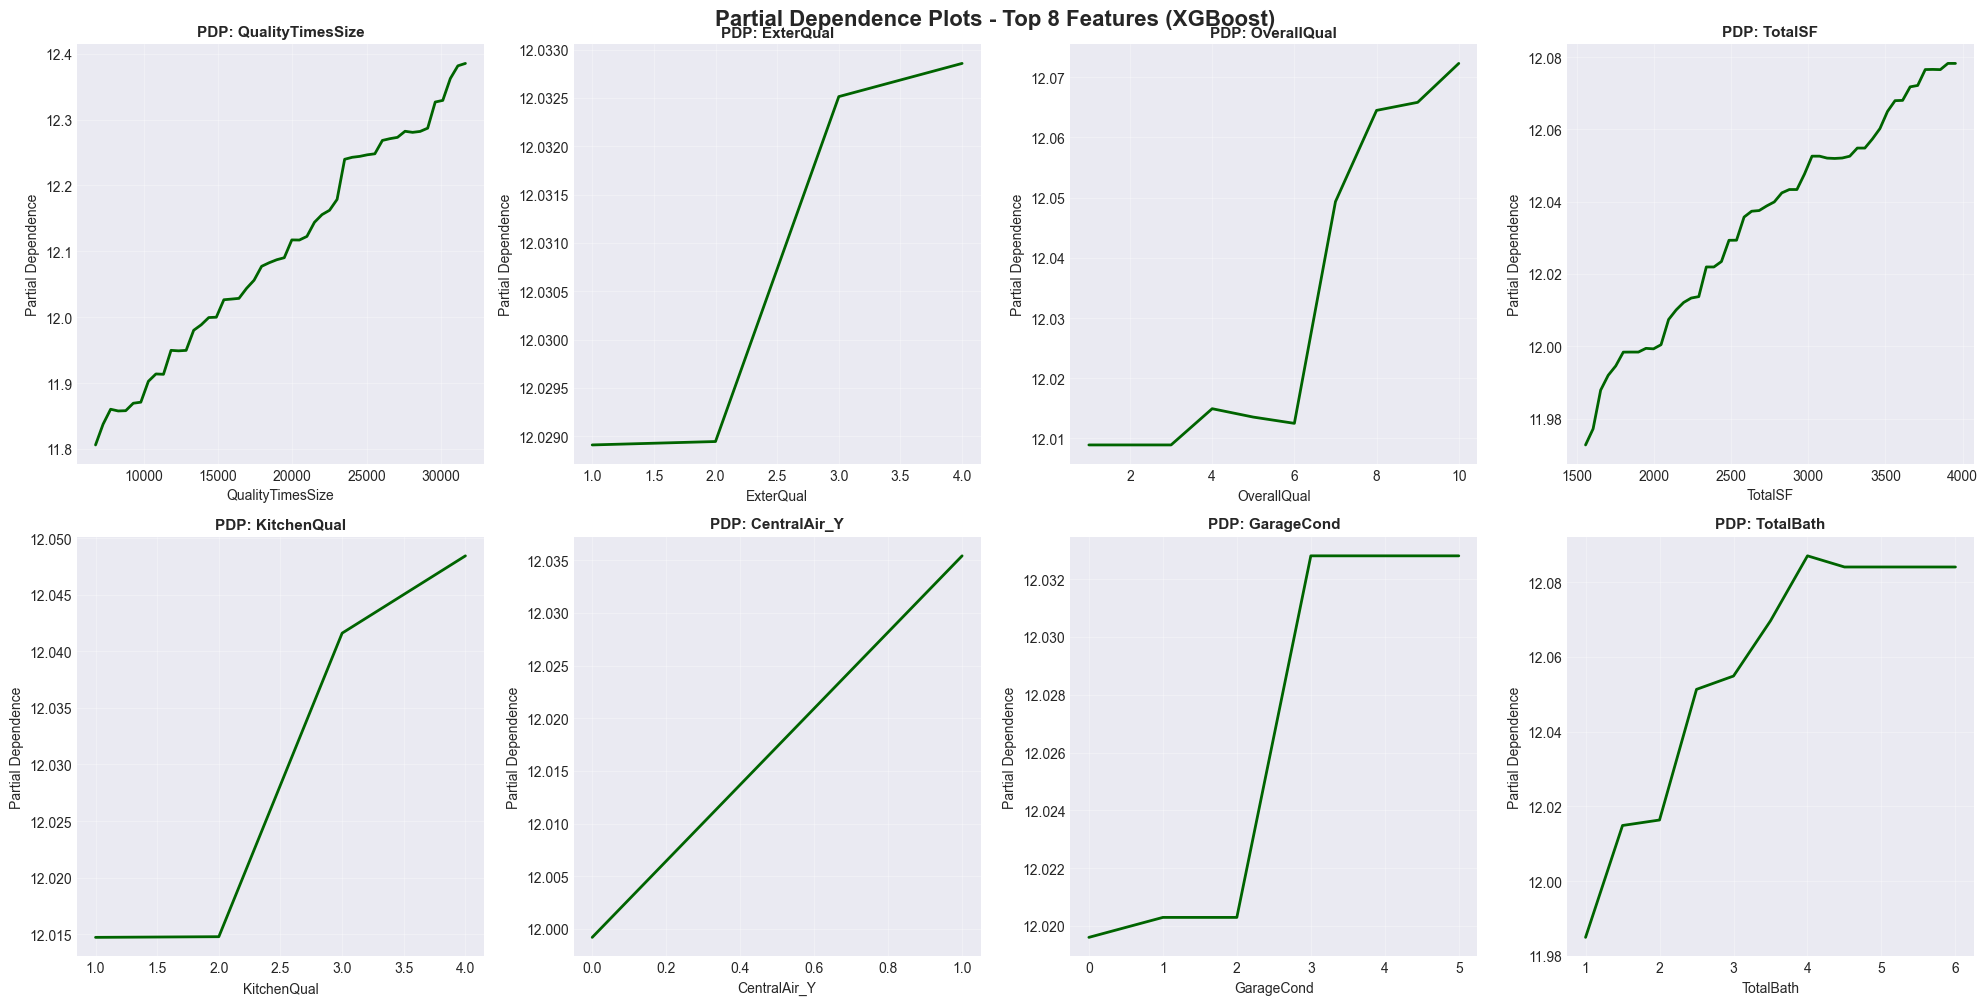

✓ 1-way Partial Dependence Plots generated


In [14]:
# Create 1-way PDPs for top features
top_features_for_pdp = xgb_feature_importance.head(8)['Feature'].tolist()
feature_indices = [X_train.columns.get_loc(feat) for feat in top_features_for_pdp]

print(f"\nGenerating Partial Dependence Plots for top 8 features...")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (feature_idx, feature_name) in enumerate(zip(feature_indices, top_features_for_pdp)):
    pd_result = partial_dependence(
        best_xgb, 
        X_train, 
        features=[feature_idx],
        grid_resolution=50
    )
    
    ax = axes[idx]
    ax.plot(pd_result['grid_values'][0], pd_result['average'][0], linewidth=2, color='darkgreen')
    ax.set_xlabel(feature_name, fontsize=10)
    ax.set_ylabel('Partial Dependence', fontsize=10)
    ax.set_title(f'PDP: {feature_name}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Partial Dependence Plots - Top 8 Features (XGBoost)', 
             fontsize=16, fontweight='bold', y=1.001)
plt.show()

print("✓ 1-way Partial Dependence Plots generated")


Generating 2-way interaction plots...


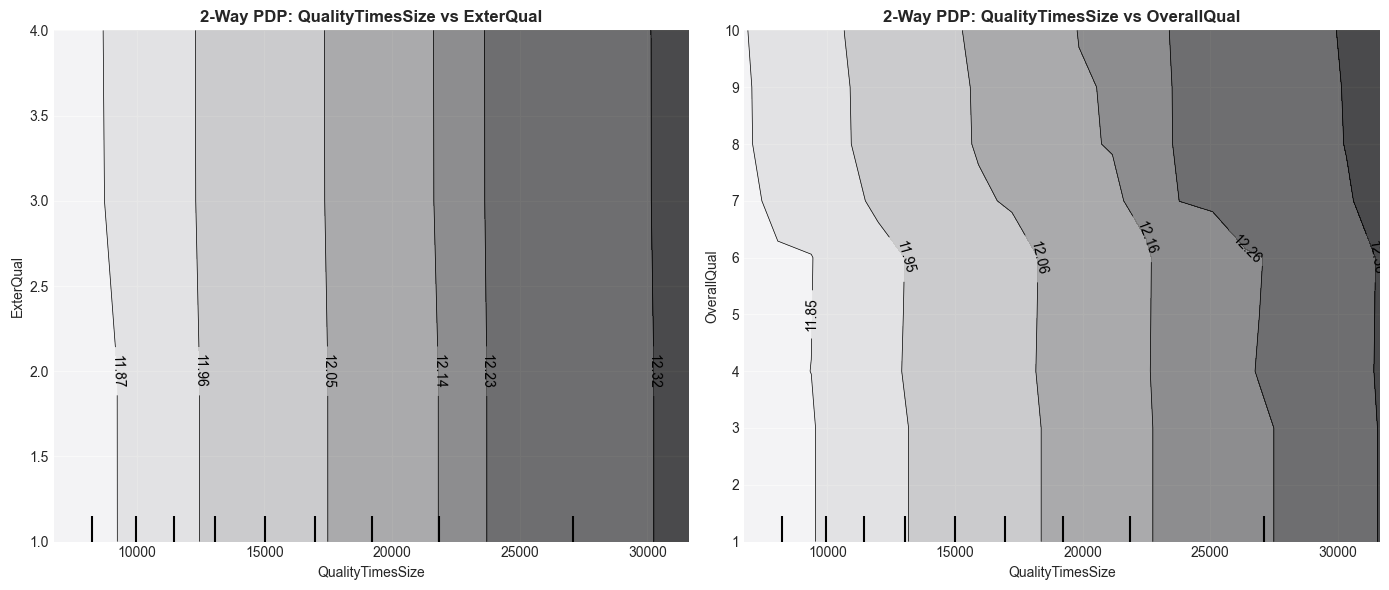

✓ 2-way Partial Dependence Plots generated

NOTEBOOK 1 COMPLETE

Next Steps:
  - Use Notebook 2 for single case inference with SHAP analysis
  - Use Notebook 3 to generate predictions for the entire test set


In [15]:
# Create 2-way interaction PDPs
print("\nGenerating 2-way interaction plots...")

top_4_features = xgb_feature_importance.head(4)['Feature'].tolist()
top_4_indices = [X_train.columns.get_loc(feat) for feat in top_4_features]

feature_pairs = [
    (top_4_indices[0], top_4_indices[1]),
    (top_4_indices[0], top_4_indices[2])
]

pair_names = [
    f"{top_4_features[0]} vs {top_4_features[1]}",
    f"{top_4_features[0]} vs {top_4_features[2]}"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()

for idx, (feature_pair, pair_name) in enumerate(zip(feature_pairs, pair_names)):
    display = PartialDependenceDisplay.from_estimator(
        best_xgb,
        X_train,
        features=[feature_pair],
        grid_resolution=20,
        ax=axes[idx]
    )
    axes[idx].set_title(f'2-Way PDP: {pair_name}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ 2-way Partial Dependence Plots generated")
print("\n" + "="*80)
print("NOTEBOOK 1 COMPLETE")
print("="*80)
print("\nNext Steps:")
print("  - Use Notebook 2 for single case inference with SHAP analysis")
print("  - Use Notebook 3 to generate predictions for the entire test set")


ELASTIC NET - FEATURE IMPORTANCE

Top 15 Features - Elastic Net Absolute Coefficients:
              Feature  Coefficient
128       OverallQual     0.131403
143      TotRmsAbvGrd     0.112271
91        AreaPerRoom     0.102059
185    Functional_Typ     0.059136
87        MSZoning_RM     0.050734
8          GarageCars     0.050605
84    Condition1_Norm     0.050076
134       OverallCond     0.040164
131          BsmtQual     0.039343
145        MSSubClass     0.035428
124  Foundation_PConc     0.033407
106      CentralAir_Y     0.031718
137  BsmtFinType1_Unf     0.031333
16    BsmtExposure_Gd     0.030603
73           HouseAge     0.029163


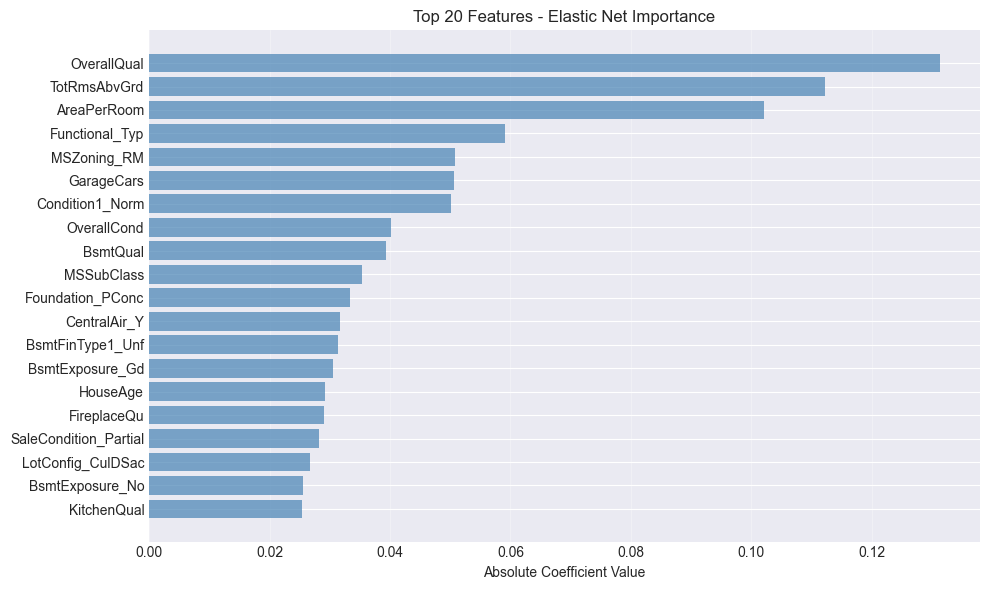

✓ Elastic Net feature importance calculated


In [16]:
# Elastic Net Feature Importance (from coefficients)
print("\n" + "="*80)
print("ELASTIC NET - FEATURE IMPORTANCE")
print("="*80)

elastic_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': np.abs(best_elastic.coef_)
}).sort_values('Coefficient', ascending=False)

print("\nTop 15 Features - Elastic Net Absolute Coefficients:")
print(elastic_coef.head(15))

# Visualize feature importance
plt.figure(figsize=(10, 6))
top_20_elastic = elastic_coef.head(20)
plt.barh(range(len(top_20_elastic)), top_20_elastic['Coefficient'], color='steelblue', alpha=0.7)
plt.yticks(range(len(top_20_elastic)), top_20_elastic['Feature'])
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 20 Features - Elastic Net Importance')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Elastic Net feature importance calculated")


Generating Partial Dependence Plots for Elastic Net top 8 features...


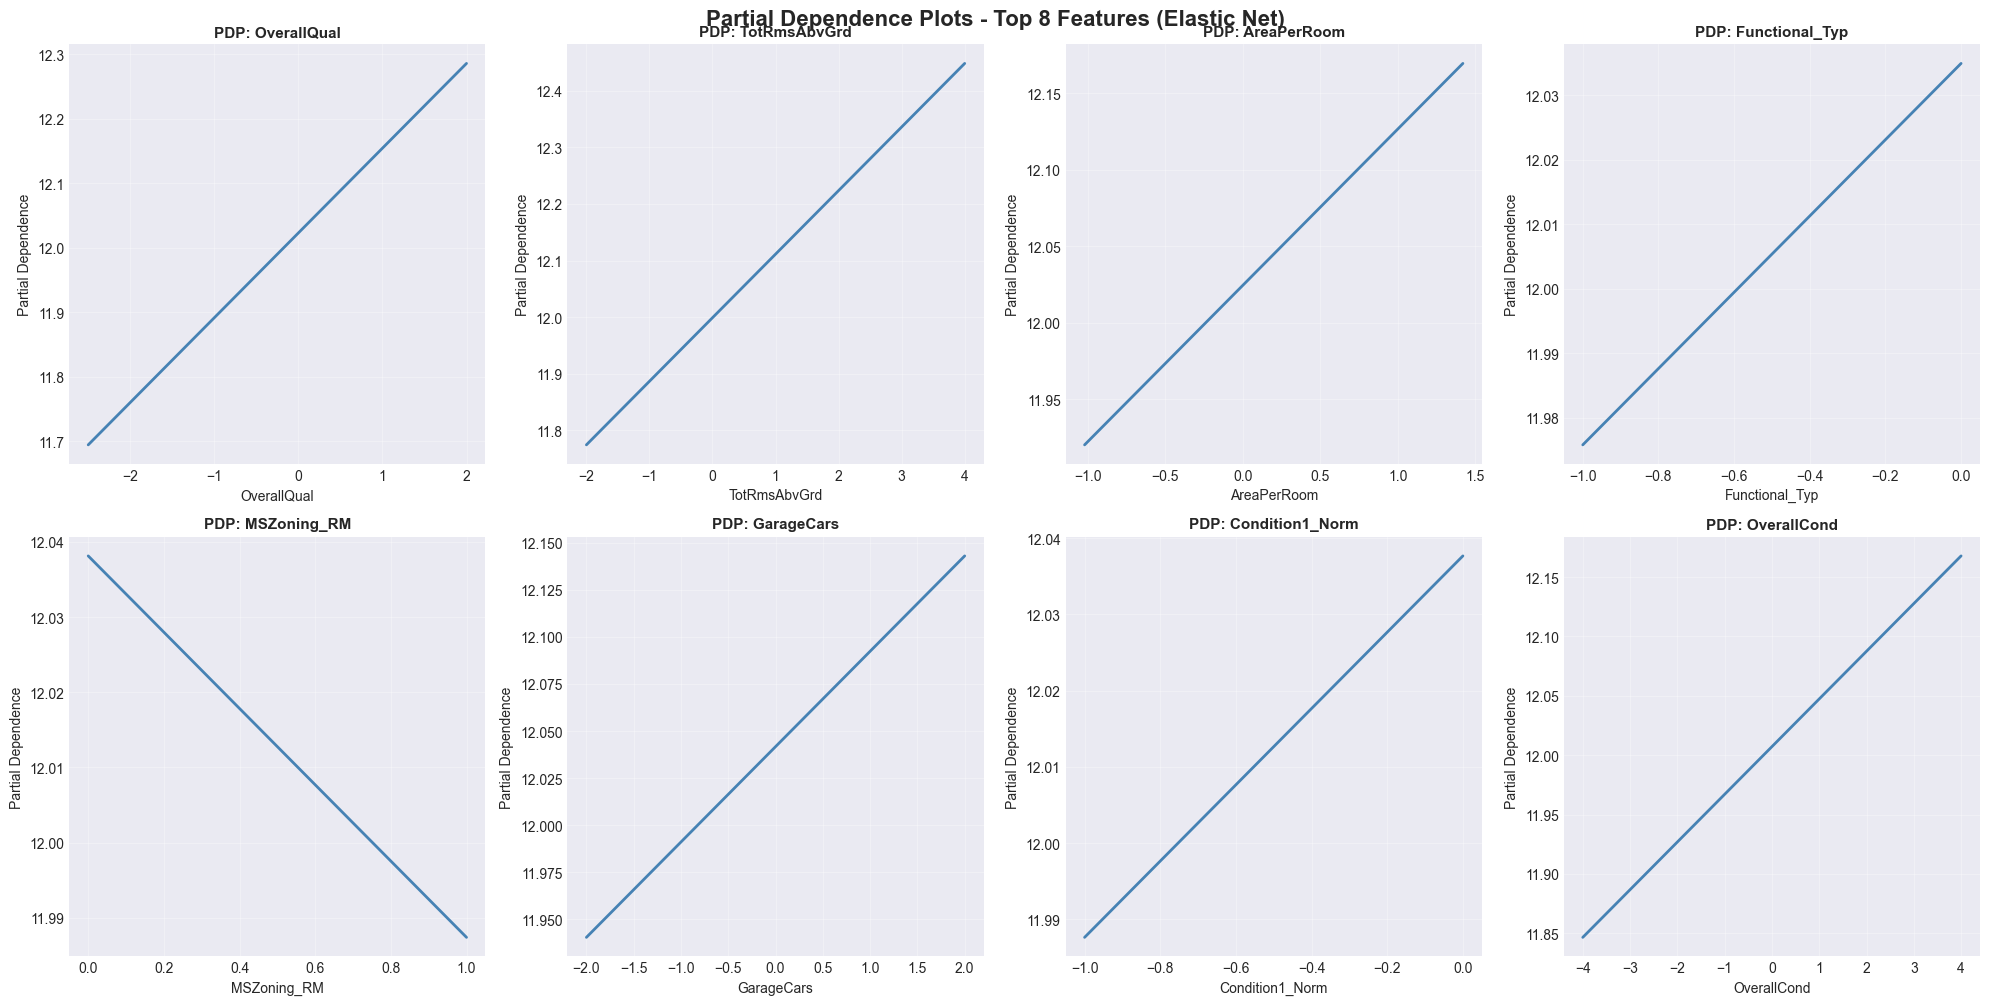

✓ Elastic Net 1-way Partial Dependence Plots generated


In [17]:
# Create 1-way PDPs for Elastic Net top features
top_features_elastic = elastic_coef.head(8)['Feature'].tolist()
feature_indices_elastic = [X_train.columns.get_loc(feat) for feat in top_features_elastic]

print(f"\nGenerating Partial Dependence Plots for Elastic Net top 8 features...")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (feature_idx, feature_name) in enumerate(zip(feature_indices_elastic, top_features_elastic)):
    pd_result = partial_dependence(
        best_elastic, 
        X_train_scaled,  # Use scaled data for Elastic Net
        features=[feature_idx],
        grid_resolution=50
    )
    
    ax = axes[idx]
    ax.plot(pd_result['grid_values'][0], pd_result['average'][0], linewidth=2, color='steelblue')
    ax.set_xlabel(feature_name, fontsize=10)
    ax.set_ylabel('Partial Dependence', fontsize=10)
    ax.set_title(f'PDP: {feature_name}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Partial Dependence Plots - Top 8 Features (Elastic Net)', 
             fontsize=16, fontweight='bold', y=1.001)
plt.show()

print("✓ Elastic Net 1-way Partial Dependence Plots generated")


Generating Elastic Net 2-way interaction plots...


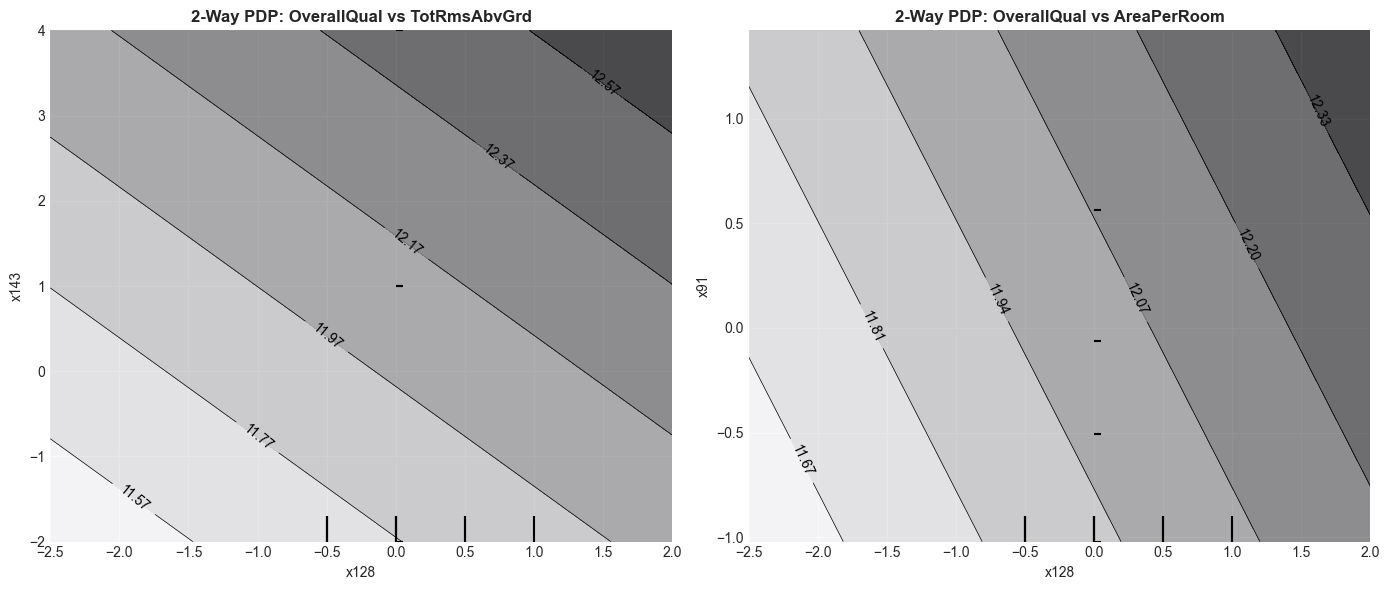

✓ Elastic Net 2-way Partial Dependence Plots generated


In [18]:
# Create 2-way interaction PDPs for Elastic Net
print("\nGenerating Elastic Net 2-way interaction plots...")

top_4_features_elastic = elastic_coef.head(4)['Feature'].tolist()
top_4_indices_elastic = [X_train.columns.get_loc(feat) for feat in top_4_features_elastic]

feature_pairs_elastic = [
    (top_4_indices_elastic[0], top_4_indices_elastic[1]),
    (top_4_indices_elastic[0], top_4_indices_elastic[2])
]

pair_names_elastic = [
    f"{top_4_features_elastic[0]} vs {top_4_features_elastic[1]}",
    f"{top_4_features_elastic[0]} vs {top_4_features_elastic[2]}"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()

for idx, (feature_pair, pair_name) in enumerate(zip(feature_pairs_elastic, pair_names_elastic)):
    display = PartialDependenceDisplay.from_estimator(
        best_elastic,
        X_train_scaled,  # Use scaled data for Elastic Net
        features=[feature_pair],
        grid_resolution=20,
        ax=axes[idx]
    )
    axes[idx].set_title(f'2-Way PDP: {pair_name}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Elastic Net 2-way Partial Dependence Plots generated")